# <span style="color:red"> QTM 151 - Quiz 5 </span>

### Submit as an **HTML file**
### Quiz is open 1:00pm to 1:55pm

<font size = "4" >
This quiz is open book 

- You can use the lecture notes
- You will get partial credit for attempting the questions
- To get full credit, the code should work as intended
- You should <span style="color:red"> NOT </span> communicate with other students

Print the following message: <br>

"I will abide by Emory's code of conduct"

In [1]:
# Write your answer here

print("I will abide by Emory's Code of Conduct")

I will abide by Emory's Code of Conduct


In [2]:
# import necessary libraries
import pandas as pd

<font size = "5">

1. Replacing strings

<font size = "4">

- Read in the data from "yelp_reviews.csv", assigning the output to a DataFrame.

- This dataset contains a large number of restaurant reviews from yelp.com. The text of each review is stored in the "review" column.

- In the "review" column, do the following:

    - Replace all instances of the word "champaign" with "Champaign" (it is a proper noun, the name of a city in Illinois)
    - Replace all instances of the phrase "Champaign Urbana" with "Champaign-Urbana".

- Make sure the replacements you make are being applied to the original DataFrame.


In [27]:
# your code here

#Reading in the CSV file and checking what it looks like
Yelp_Reviews = pd.read_csv("data_quiz/yelp_reviews.csv")
print(Yelp_Reviews.head())

#Replacing the words as per instructions here
Yelp_Reviews["review"] = Yelp_Reviews["review"].str.replace("champaign", "Champaign")
Yelp_Reviews["review"] = Yelp_Reviews["review"].str.replace("champaign Urbana", "Champaign-Urbana")


                                                 url  rating       date  \
0  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5  1/22/2022   
1  https://www.yelp.com/biz/sidney-dairy-barn-sidney       4  6/26/2022   
2  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5   8/7/2021   
3  https://www.yelp.com/biz/sidney-dairy-barn-sidney       4  7/28/2016   
4  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5  6/23/2015   

                                              review  
0  All I can say is they have very good ice cream...  
1  Nice little local place for ice cream.My favor...  
2  A delicious treat on a hot day! Staff was very...  
3  This was great service and a fun crew! I got t...  
4  This is one of my favorite places to get ice c...  


<font size = "5">

2. Look for reviews containing a string pattern

<font size = "4">

- Search for all reviews that contain a string describing a range of years, such as "1992-1998" or "2000-2007".

- Create a DataFrame called ``df_year`` that consists of all the rows of the original DataFrame for which you found a range of years in the Yelp review.

- We can characterize a range of years as: 4 digit characters, followed by a dash, followed by 4 digit characters.


In [26]:
# your code here

df_year = Yelp_Reviews[Yelp_Reviews["review"].str.contains(r'\d{4}-\d{4}')]
print(df_year)



                                                     url  rating       date  \
12240  https://www.yelp.com/biz/prestis-bakery-cleveland       5   9/7/2008   
14737  https://www.yelp.com/biz/jarlings-custard-cup-...       4  8/18/2009   
17759  https://www.yelp.com/biz/masons-creamery-cleve...       5  10/2/2016   

                                                  review  \
12240  Lived in Cleveland Heights for 5 years (1987-1...   
14737  On a journey to revisit my mom's college town,...   
17759  Very yummy vegan ice creams. The moment you st...   

                                                  tokens  
12240  [lived, in, cleveland, heights, for, years, pr...  
14737  [on, a, journey, to, revisit, my, mom's, colle...  
17759  [very, yummy, vegan, ice, creams, the, moment,...  


<font size = "5">

3. Find similarly spelled words

<font size = "4">

- Find all occurences of the words "place", "places", "plate", and "plates" in the reviews by using ``.str.findall`` **one time**. This should be in the form of a Pandas Series where each row is a list that either contains the found strings or is empty.

- Use the ``.str.len`` method to create a Pandas Series that only includes the rows where a match was found. (Put another way, the Series should exclude all the empty lists where no match was found)

In [25]:
# your code here

df_place = Yelp_Reviews["review"].str.findall(r'\bplace\b|\bplaces\b|\bplate\b|\bplates\b')
df_place_len = df_place[df_place.str.len() > 0]

print(df_place_len)


1         [place]
4        [places]
5         [place]
6         [place]
7         [place]
           ...   
19871     [place]
19874     [place]
19879     [place]
19884     [place]
19887     [place]
Name: review, Length: 7409, dtype: object


<font size = "5">

4. Find words ending with "y"

<font size = "4">

- Find all words ending with the letter "y" by using ``.str.findall``. This should be in the form of a Pandas Series where each row is a list that either contains the found strings or is empty.

- Specifically, you are looking for one or more consecutive alphabetical characters (both upper and lower case) or apostrophe (single quote) characters followed by the letter "y".

- In order to ensure that the word **ends** with "y", add the special character "\\\b" (two backslashes and a "b") immediately after the "y". This is called a word boundary.

- Use the ``.str.len`` method to create a Pandas Series that only includes the rows where a match was found. (Put another way, the Series should exclude all the empty lists where no match was found)



In [24]:
# your code here

Question_4 = Yelp_Reviews["review"].str.findall(r"[A-Z,a-z']+y/b")
Question_4_len = Question_4[Question_4.str.len() > 0]

print(Question_4_len)

2643          [study/b]
4811          [silky/b]
5043          [nutty/b]
7328          [nutty/b]
8449         [creamy/b]
9629     [strawberry/b]
11698        [smokey/b]
12723        [Pastry/b]
Name: review, dtype: object


<font size = "5">

5. Convert reviews to individual words

<font size = "4">

- Add a new column to the DataFrame with the name "tokens", where each row of the column is a list containing all individual words appearing in the Yelp review for that row.

- For the purposes of this question, we will take a single word to be one or more consecutive occurrences of the letters, A-Z, a-z, and the apostrophe character.

- Then use ``.apply`` to ensure every word in the "tokens" column is lowercase. Make sure you are actually changing the "tokens" column of the DataFrame in this step.

- **Note:** There are no "NaNs" in the "review" column, so it shouldn't be necessary to account for the case where an entry in the "tokens" column isn't actually a list.

In [23]:
# your code here
Yelp_Reviews["tokens"] = Yelp_Reviews["review"].str.findall(r"[A-Z',a-z']+")
Yelp_Reviews["tokens"] = Yelp_Reviews["tokens"].apply(lambda x: [word.lower() for word in x])
print(Yelp_Reviews.head())

                                                 url  rating       date  \
0  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5  1/22/2022   
1  https://www.yelp.com/biz/sidney-dairy-barn-sidney       4  6/26/2022   
2  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5   8/7/2021   
3  https://www.yelp.com/biz/sidney-dairy-barn-sidney       4  7/28/2016   
4  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5  6/23/2015   

                                              review  \
0  All I can say is they have very good ice cream...   
1  Nice little local place for ice cream.My favor...   
2  A delicious treat on a hot day! Staff was very...   
3  This was great service and a fun crew! I got t...   
4  This is one of my favorite places to get ice c...   

                                              tokens  
0  [all, i, can, say, is, they, have, very, good,...  
1  [nice, little, local, place, for, ice, cream, ...  
2  [a, delicious, treat, on, a, hot, day, staff

<font size = "5">

6. Convert reviews to individual words

<font size = "4">

- Unravel the values from "tokens" into a single Pandas Series containing all the words appearing in every review.

- Then, create a new Pandas Series containing the probabilities/proportions of each word. This Pandas Series will have an index column (the tokens/words) and the single "proper" column will be the proportions/probabilities.

- Create a bar plot of the probabilities of the 13 most frequently occuring words in the dataset. Add a label to the y-axis and a title.

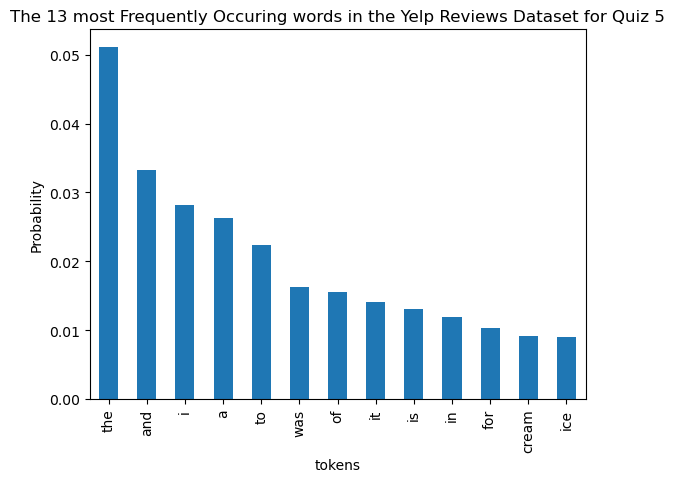

In [22]:
# your code here
import matplotlib.pyplot as plt

#Creating the word counts and probabilities
question_6 = Yelp_Reviews["tokens"].explode()
question_6_word_counts = question_6.value_counts()
question_6_probabilities = question_6_word_counts / question_6_word_counts.sum()
question_6_top13_probabilities = question_6_probabilities.head(13)

#Plotting!
question_6_top13_probabilities.plot(kind = "bar")
plt.ylabel("Probability")
plt.title("The 13 most Frequently Occuring words in the Yelp Reviews Dataset for Quiz 5")
plt.show()

